# SEA Full Pipeline: From Raw Video to Aligned Subtitles

This notebook runs the **complete 4-stage SEA pipeline** on a Thai Sign Language video, starting from a raw `.mp4` file and producing aligned `.vtt` subtitles.

```
Stage 0: Pose Estimation       .mp4  →  .pose     (MediaPipe Holistic)
Stage 1: Sign Segmentation     .pose →  .eaf      (pose_to_segments → SIGN tier)
Stage 2: Embedding (optional)  .pose + .vtt → .npy (SignCLIP / SentenceTransformer)
Stage 3: DP Alignment          .eaf + .vtt  →  aligned .vtt + updated .eaf
```

### What makes this different from a Stage-3-only demo?

A Stage-3-only demo reads human-annotated sign segments directly from a pre-labeled `.eaf` file. This notebook starts from scratch with only:

1. **`04.mp4`** — the raw video
2. **`.vtt` subtitles** — extracted from the `.eaf` file's `CC` tier (172 cues, 0.0–663.6 s; in production these would come from ASR)

The human-annotated `Gloss Labeling` tier is kept only as **ground truth for evaluation** and as the sign-segment source for `text_embedding` mode.

### Pipeline diagram

```
┌──────────────────────────────────────────────────────────────────────────┐
│                          SEA 4-STAGE PIPELINE                              │
│                                                                            │
│  ┌──────────┐     ┌──────────────────┐     ┌──────────────────┐           │
│  │  Input   │     │   STAGE 0        │     │   STAGE 1        │           │
│  │  Video   │───▶│  Pose Estimation │───▶│  Sign            │           │
│  │  .mp4    │     │  (MediaPipe)     │     │  Segmentation    │           │
│  └──────────┘     │  .mp4 → .pose    │     │  .pose → .eaf    │           │
│                   └──────────────────┘     └────────┬─────────┘           │
│                                                    │                      │
│  ┌──────────┐     ┌──────────────────┐             │                      │
│  │Subtitles │     │   STAGE 2        │             │                      │
│  │ .vtt/srt │───▶│  Embedding       │─────────────┤                      │
│  └──────────┘     │  (SignCLIP /     │  .npy       │                      │
│                   │  SentenceTrans.) │             │                      │
│                   └──────────────────┘             ▼                      │
│                                           ┌──────────────────┐           │
│  ┌──────────┐                             │   STAGE 3        │           │
│  │Subtitles │────────────────────────────▶│  DP Alignment    │           │
│  │ .vtt/srt │                             │  (align_dp.py)   │           │
│  └──────────┘                             └────────┬─────────┘           │
│                                                    │                      │
│                                           ┌─────────┴────────┐           │
│                                           │  OUTPUT           │           │
│                                           │  *_updated.eaf    │           │
│                                           │  aligned .vtt     │           │
│                                           └──────────────────┘           │
└──────────────────────────────────────────────────────────────────────────┘
```

---
## Section 1 — Environment & Path Setup

### Prerequisites

```bash
# Option A: using uv (recommended)
curl -LsSf https://astral.sh/uv/install.sh | sh   # install uv if needed
uv sync                                             # creates .venv/ and installs all deps
source .venv/bin/activate

# Option B: using pip
python3.12 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
```

Key packages:
- **`pose-format`** — `videos_to_poses` CLI (Stage 0)
- **`sign-language-segmentation`** — `pose_to_segments` CLI (Stage 1)
- **`mediapipe`** — pose estimation backend
- **`sentence-transformers`** — text embedding for Stage 2 (`text_embedding` mode)
- **`numba`** — JIT compiler for the DP inner loop (Stage 3)
- **`pympi-ling`** / **`webvtt-py`** — ELAN and VTT I/O

### GPU support

| Stage | GPU used? | Notes |
|-------|-----------|-------|
| 0 — Pose Estimation | **Yes** (CUDA) | MediaPipe uses GPU if available; CPU fallback on macOS |
| 1 — Segmentation | No | Small model, CPU-only, runs in seconds |
| 2 — Embedding | **Yes** (CUDA) | SentenceTransformer / SignCLIP use GPU if available |
| 3 — DP Alignment | No | Numba JIT on CPU (already very fast) |

In [1]:
import sys
import os
import glob
import shutil
import subprocess
import copy
from pathlib import Path

# -- Repository paths ---------------------------------------------------------
REPO_ROOT = Path("..").resolve()
SEA_DIR = REPO_ROOT / "SEA"
MISC_DIR = SEA_DIR / "misc"
DATA_DIR = REPO_ROOT / "data" / "example_alignment"
OUTPUT_DIR = DATA_DIR / "pipeline_output"
ASSETS_DIR = REPO_ROOT / "assets"

# Evaluation policy: require independent subtitle GT for valid metrics.
STRICT_INDEPENDENT_GT = True

# Add SEA modules to import path
for p in [str(SEA_DIR), str(MISC_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Create output subdirectories
for subdir in ["pose_input", "poses", "subtitles", "ground_truth",
               "segmentation", "aligned", "aligned_gt_signs"]:
    (OUTPUT_DIR / subdir).mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(exist_ok=True)

# -- GPU / device detection ---------------------------------------------------
import torch
import numba
import pympi
import mediapipe

CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"
print(f"PyTorch {torch.__version__}  |  CUDA: {CUDA_AVAILABLE}  |  Device: {DEVICE}")
if CUDA_AVAILABLE:
    props = torch.cuda.get_device_properties(0)
    total_vram = getattr(props, "total_memory", getattr(props, "total_mem", 0))
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {total_vram / 1e9:.1f} GB")
print(f"Numba {numba.__version__}  |  MediaPipe {mediapipe.__version__}")
print(f"\nREPO_ROOT:  {REPO_ROOT}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"STRICT_INDEPENDENT_GT: {STRICT_INDEPENDENT_GT}")

PyTorch 2.7.0+cu128  |  CUDA: True  |  Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM: 17.1 GB
Numba 0.62.1  |  MediaPipe 0.10.21

REPO_ROOT:  C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub
OUTPUT_DIR: C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\pipeline_output
STRICT_INDEPENDENT_GT: True


---
## Section 2 — Preprocessing: Extract VTT from EAF

### Which subtitle tier to use: CC vs CC_Aligned

The `.eaf` file contains two subtitle tiers:

| Tier | Cues | Time range | Content |
| --- | --- | --- | --- |
| `CC` | **172** | 0.0 s – 663.6 s | Full transcript including intro/outro music annotations `[เสียงดนตรี]` |
| `CC_Aligned` | 119 | 33.6 s – 640.8 s | Signed portion only; manually refined from CC |

**We use the `CC` tier** because the external reference alignment `aligned_output.vtt` was produced from the CC tier (172 entries). Using CC_Aligned (119 cues) against a 172-cue GT would cause a cue-count mismatch that makes all offset metrics meaningless and F1 scores near zero.

The two bracketed music cues (`[เสียงดนตรี]` at 0–32 s and 650–663 s) are automatically filtered out by the evaluation function, leaving **170 matched subtitle pairs** for metric computation. The DP aligner treats the first music cue as a very short-duration placeholder that the gap/duration penalties push toward the earliest detected sign segment.

### What this cell does

1. Parses the EAF file and extracts CC tier cues (172 entries) → writes `pipeline_output/subtitles/04.vtt`
2. Loads `aligned_output.vtt` as the ground-truth reference (independently produced, 172 matching cues)
3. Extracts the `Gloss Labeling` tier as GT sign segments (used by the evaluator and by `text_embedding` mode)

In [2]:
import xml.etree.ElementTree as ET
import webvtt


def _sec_to_vtt_time(seconds: float) -> str:
    total_ms = max(0, int(round(seconds * 1000)))
    h = total_ms // 3_600_000
    m = (total_ms % 3_600_000) // 60_000
    s = (total_ms % 60_000) // 1000
    ms = total_ms % 1000
    return f"{h:02d}:{m:02d}:{s:02d}.{ms:03d}"


def _write_vtt(cues, out_vtt_path):
    out_vtt_path = Path(out_vtt_path)
    out_vtt_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_vtt_path, "w", encoding="utf-8") as f:
        f.write("WEBVTT\n\n")
        for cue in cues:
            start_ts = _sec_to_vtt_time(cue["start"])
            end_ts = _sec_to_vtt_time(cue["end"])
            f.write(f"{start_ts} --> {end_ts}\n")
            f.write(f"{cue['text']}\n\n")


def eaf_tier_to_cues(eaf_path, tier_name):
    """Extract one ELAN tier as cue dicts with absolute timeline seconds.

    Returns dicts with keys: 'start', 'end', 'mid', 'text'
    - 'start' / 'end': segment boundary in seconds (float)
    - 'mid': midpoint (start + end) / 2 — used by the DP aligner for candidate
      window selection and by the segmentation-inspection utilities
    - 'text': annotation value string (may be empty for sign segments)
    """
    tree = ET.parse(eaf_path)
    root = tree.getroot()

    # EAF stores all timestamps in milliseconds; convert to seconds up-front
    time_slots = {}
    for ts in root.find("TIME_ORDER").findall("TIME_SLOT"):
        ts_id = ts.get("TIME_SLOT_ID")
        ts_val = ts.get("TIME_VALUE")
        if ts_val is not None:
            time_slots[ts_id] = float(ts_val) / 1000.0

    tier = None
    for t in root.findall("TIER"):
        if t.get("TIER_ID") == tier_name:
            tier = t
            break
    if tier is None:
        raise ValueError(f"Tier '{tier_name}' not found in {eaf_path}")

    cues = []
    for ann in tier.findall("ANNOTATION"):
        elem = next(iter(ann), None)
        if elem is None:
            continue
        text_node = elem.find("ANNOTATION_VALUE")
        text = (text_node.text or "").strip() if text_node is not None else ""
        start = time_slots.get(elem.get("TIME_SLOT_REF1"))
        end = time_slots.get(elem.get("TIME_SLOT_REF2"))
        if start is None or end is None:
            continue
        # 'mid' is required by dp_align_subtitles_to_signs for candidate-window
        # selection. Including it here makes this function usable for BOTH
        # subtitle cues and sign-segment cues.
        cues.append({"start": start, "end": end, "mid": (start + end) / 2, "text": text})
    return cues


def vtt_to_cues(vtt_path):
    cues = []
    for cap in webvtt.read(str(vtt_path)):
        cues.append({"start": float(cap.start_in_seconds), "end": float(cap.end_in_seconds),
                     "mid": (float(cap.start_in_seconds) + float(cap.end_in_seconds)) / 2,
                     "text": cap.text})
    return cues


# Find the EAF file (Thai filename — use glob)
eaf_files = glob.glob(str(DATA_DIR / "*.eaf"))
assert len(eaf_files) >= 1, f"No .eaf files found in {DATA_DIR}"
EAF_PATH = eaf_files[0]
print(f"EAF file: {Path(EAF_PATH).name}")

subtitle_vtt_path = OUTPUT_DIR / "subtitles" / "04.vtt"
gt_vtt_path = OUTPUT_DIR / "ground_truth" / "04.vtt"
subtitle_vtt_path.parent.mkdir(parents=True, exist_ok=True)
gt_vtt_path.parent.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Input subtitles — CC tier (full transcript, 172 cues, 0.0 s – 663.6 s)
#
# We use CC (not CC_Aligned) because the external GT file aligned_output.vtt
# was produced from the CC tier (172 entries). Using CC_Aligned (119 cues)
# would cause a cue-count mismatch that breaks all offset metrics.
#
# The two bracketed music cues ([เสียงดนตรี]) at 0–32 s and 650–663 s are
# automatically excluded by the evaluator (it strips [..] annotations),
# leaving 170 matched subtitle pairs for metric computation.
# ---------------------------------------------------------------------------
input_cues = eaf_tier_to_cues(EAF_PATH, "CC")
if not input_cues:
    raise RuntimeError("No CC cues found. Cannot continue.")
_write_vtt(input_cues, subtitle_vtt_path)

# ---------------------------------------------------------------------------
# Ground truth — aligned_output.vtt (172 cues, independently produced from CC)
# ---------------------------------------------------------------------------
external_gt_candidates = [
    DATA_DIR / "aligned_output.vtt",
]

gt_source_vtt = next((p for p in external_gt_candidates if p.exists()), None)
if gt_source_vtt is not None:
    gt_cues = vtt_to_cues(gt_source_vtt)
    if not gt_cues:
        raise RuntimeError(f"GT file has no cues: {gt_source_vtt}")
    GT_SOURCE_LABEL = str(gt_source_vtt)
    EVAL_SELF_REFERENCE = False

    # Sanity check: cue count should match for valid offset metrics
    if len(gt_cues) != len(input_cues):
        import warnings
        warnings.warn(
            f"\n  GT cue count ({len(gt_cues)}) ≠ input cue count ({len(input_cues)}).\n"
            f"  Offset metrics will be MEANINGLESS. Frame-level F1 is partially valid.\n"
            f"  To fix: ensure aligned_output.vtt and input tier have the same number of cues.",
            UserWarning,
            stacklevel=1,
        )
else:
    GT_SOURCE_LABEL = "missing:independent-gt"
    EVAL_SELF_REFERENCE = True
    if STRICT_INDEPENDENT_GT:
        raise RuntimeError(
            "Independent subtitle GT not found at data/example_alignment/aligned_output.vtt. "
            "Set STRICT_INDEPENDENT_GT = False to run in sanity-check mode instead."
        )
    gt_cues = [dict(c) for c in input_cues]

_write_vtt(gt_cues, gt_vtt_path)

print(f"Input tier:  CC  ({len(input_cues)} cues)")
print(f"Input range: {input_cues[0]['start']:.1f}s – {input_cues[-1]['end']:.1f}s")
print(f"GT cues:     {len(gt_cues)}")
print(f"GT range:    {gt_cues[0]['start']:.1f}s – {gt_cues[-1]['end']:.1f}s")
print(f"GT source:   {GT_SOURCE_LABEL}")
if len(gt_cues) == len(input_cues):
    print("✓ Cue counts match — offset metrics and F1 scores will be valid.")
else:
    print(f"⚠  Cue count mismatch ({len(gt_cues)} GT vs {len(input_cues)} pred): "
          f"offset metrics will be unreliable.")
if EVAL_SELF_REFERENCE:
    print("NOTE: GT is self-referential (same as input). "
          "Metrics show timestamp shift from baseline, not absolute accuracy.")
print(f"Written input VTT: {subtitle_vtt_path}")
print(f"Written GT VTT:    {gt_vtt_path}")

EAF file: การเปรียบเทียบและเรียงลำดับ (11.07 นาที).eaf
Input tier:  CC  (172 cues)
Input range: 0.0s – 663.6s
GT cues:     172
GT range:    0.0s – 663.6s
GT source:   C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\aligned_output.vtt
✓ Cue counts match — offset metrics and F1 scores will be valid.
Written input VTT: C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\pipeline_output\subtitles\04.vtt
Written GT VTT:    C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\pipeline_output\ground_truth\04.vtt


In [3]:
# ── Extract Gloss Labeling tier → ground truth sign segments (in memory) ───
# eaf_tier_to_cues (defined above in Section 2) returns dicts with keys:
#   'start', 'end', 'mid', 'text'
# The 'mid' key is required by dp_align_subtitles_to_signs for candidate
# window selection — it does NOT need to be added separately here.
gt_sign_segments = eaf_tier_to_cues(EAF_PATH, "Gloss Labeling")

print(f"Ground truth sign segments (Gloss Labeling): {len(gt_sign_segments)}")
print(f"Time range: {gt_sign_segments[0]['start']:.1f}s – {gt_sign_segments[-1]['end']:.1f}s")
print(f"\nFirst 5 segments:")
for seg in gt_sign_segments[:5]:
    print(f"  [{seg['start']:7.2f}s – {seg['end']:7.2f}s]  {seg['text']}")

Ground truth sign segments (Gloss Labeling): 852
Time range: 33.6s – 646.6s

First 5 segments:
  [  33.56s –   34.61s]  สวัสดี
  [  35.09s –   35.77s]  (ผายมือ)
  [  35.99s –   36.09s]  เด็ก
  [  36.29s –   36.62s]  เรียน
  [  36.79s –   37.33s]  (ผายมือ)


---
## Section 3 — Stage 0: Video Crop (Right Half) + Pose Estimation

**Input:** `04.mp4` (raw video)  
**Intermediate:** `04_right_half.mp4` (cropped to right half)  
**Output:** `04.pose` (binary file containing per-frame body/hand/face landmarks)  
**Tool:** `videos_to_poses` CLI from the [`pose-format`](https://github.com/sign-language-processing/pose) package

### What happens inside

1. The notebook crops each frame to the **right half** of the video (`x = width/2 ... width`).
2. `MediaPipe Holistic` then processes the cropped video and extracts:
- 33 body landmarks (BlazePose) + 468 face mesh + 21×2 hand landmarks = **543 landmarks per frame**
- Each landmark has (x, y, z, visibility) coordinates

### GPU acceleration

When CUDA is available, `videos_to_poses` uses the GPU for pose estimation, reducing processing time from ~10 min to ~1–2 min. The `--additional-config` flag allows setting MediaPipe options:
- `model_complexity=2` — highest accuracy (default=1)
- `refine_face_landmarks=true` — more precise face mesh
- `smooth_landmarks=false` — disable temporal smoothing (better for segmentation)

### Performance

| Platform | Time (11-min video) |
|----------|--------------------|
| macOS (CPU) | ~5–15 min |
| Linux (GPU) | ~1–2 min |

The cropped video and pose file are cached — re-running skips computation if outputs already exist.

In [4]:
# -- Stage 0: Crop video (right half) + Pose estimation ----------------------
import cv2

RAW_VIDEO_FILE = DATA_DIR / "04.mp4"
CROPPED_VIDEO_DIR = OUTPUT_DIR / "cropped_videos"
CROPPED_VIDEO_DIR.mkdir(parents=True, exist_ok=True)
CROPPED_VIDEO_FILE = CROPPED_VIDEO_DIR / "04_right_half.mp4"

POSE_INPUT_DIR = OUTPUT_DIR / "pose_input"
POSE_DIR = OUTPUT_DIR / "poses"
POSE_FILE = POSE_DIR / "04.pose"


def crop_video_to_right_half(src_path: Path, dst_path: Path):
    """Crop input video to the right half, preserving FPS and audio."""
    cap = cv2.VideoCapture(str(src_path))
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video: {src_path}")

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0

    right_x = width // 2
    crop_width = width - right_x

    temp_video = dst_path.with_suffix(".video_tmp.mp4")
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(temp_video), fourcc, fps, (crop_width, height))
    if not writer.isOpened():
        cap.release()
        raise RuntimeError(f"Failed to create temp cropped video: {temp_video}")

    frame_count = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        cropped = frame[:, right_x:width]
        writer.write(cropped)
        frame_count += 1

    cap.release()
    writer.release()

    if frame_count == 0:
        if temp_video.exists():
            temp_video.unlink()
        raise RuntimeError("No frames were written during crop.")

    # Keep original audio by muxing it back with ffmpeg when available.
    ffmpeg_path = shutil.which("ffmpeg")
    if ffmpeg_path:
        cmd = [
            ffmpeg_path, "-y",
            "-i", str(temp_video),
            "-i", str(src_path),
            "-map", "0:v:0",
            "-map", "1:a?",
            "-c:v", "copy",
            "-c:a", "copy",
            "-shortest",
            str(dst_path),
        ]
        result = subprocess.run(cmd, capture_output=True, text=True, encoding="utf-8", errors="replace")
        if result.returncode != 0:
            print("Warning: ffmpeg audio mux failed; using cropped video without audio.")
            print(result.stderr.strip()[:500])
            shutil.move(str(temp_video), str(dst_path))
        else:
            temp_video.unlink(missing_ok=True)
    else:
        print("ffmpeg not found; writing cropped video without audio track.")
        shutil.move(str(temp_video), str(dst_path))


if CROPPED_VIDEO_FILE.exists():
    print(f"Cropped video already exists: {CROPPED_VIDEO_FILE}")
else:
    print("Cropping raw video to right half...")
    crop_video_to_right_half(RAW_VIDEO_FILE, CROPPED_VIDEO_FILE)
    print(f"Done. Cropped video: {CROPPED_VIDEO_FILE}")

# Prepare input file for videos_to_poses. On Windows, symlink may require elevated privilege.
video_link = POSE_INPUT_DIR / "04.mp4"
if video_link.exists() or video_link.is_symlink():
    video_link.unlink()
try:
    os.symlink(CROPPED_VIDEO_FILE.resolve(), video_link)
    print(f"Created symlink: {video_link} -> {CROPPED_VIDEO_FILE}")
except OSError as e:
    print(f"Symlink failed ({e}). Falling back to file copy.")
    shutil.copy2(CROPPED_VIDEO_FILE, video_link)
    print(f"Copied file: {CROPPED_VIDEO_FILE} -> {video_link}")

if POSE_FILE.exists():
    print(f"Pose file already exists: {POSE_FILE}")
    print(f"Size: {POSE_FILE.stat().st_size / 1e6:.1f} MB")
    print("Skipping Stage 0. Delete the file to re-run.")
else:
    print("Running Stage 0: Pose estimation from RIGHT-HALF cropped video...")
    if not CUDA_AVAILABLE:
        print("No GPU detected - running on CPU (may take 5-15 minutes).")
    else:
        print(f"GPU detected ({torch.cuda.get_device_name(0)}) - should take 1-2 minutes.")
    print()

    cmd = [
        "videos_to_poses",
        "--format", "mediapipe",
        "--directory", str(POSE_INPUT_DIR),
        # Higher accuracy settings (same as SEA/README.md example)
        '--additional-config=model_complexity=2,smooth_landmarks=false,refine_face_landmarks=true',
    ]
    print(f"Command: {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True, encoding="utf-8", errors="replace")

    if result.returncode != 0:
        print(f"STDOUT: {result.stdout}")
        print(f"STDERR: {result.stderr}")
        raise RuntimeError("Pose estimation failed. See output above.")

    # videos_to_poses writes .pose next to .mp4 - move it to our poses/ dir
    generated = POSE_INPUT_DIR / "04.pose"
    if generated.exists():
        shutil.move(str(generated), str(POSE_FILE))
    else:
        candidates = list(POSE_INPUT_DIR.glob("*.pose")) + list(CROPPED_VIDEO_DIR.glob("*.pose")) + list(DATA_DIR.glob("*.pose"))
        if candidates:
            shutil.move(str(candidates[0]), str(POSE_FILE))
        elif not POSE_FILE.exists():
            raise FileNotFoundError("Could not find the generated .pose file")

    print(f"\nDone. Pose file: {POSE_FILE}")
    print(f"Size: {POSE_FILE.stat().st_size / 1e6:.1f} MB")

Cropped video already exists: C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\pipeline_output\cropped_videos\04_right_half.mp4
Symlink failed ([WinError 1314] A required privilege is not held by the client: 'C:\\Users\\USER\\Documents\\Dechathon_N\\Learning\\ELAN\\Sign_to_sub\\data\\example_alignment\\pipeline_output\\cropped_videos\\04_right_half.mp4' -> 'C:\\Users\\USER\\Documents\\Dechathon_N\\Learning\\ELAN\\Sign_to_sub\\data\\example_alignment\\pipeline_output\\pose_input\\04.mp4'). Falling back to file copy.
Copied file: C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\pipeline_output\cropped_videos\04_right_half.mp4 -> C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\pipeline_output\pose_input\04.mp4
Pose file already exists: C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\pipeline_output\poses\04.pose
Size: 374.9 MB
Skipping Stage 0. 

In [5]:
# ── Verify the pose file ──────────────────────────────────────────────────
from pose_format import Pose

with open(POSE_FILE, "rb") as f:
    pose = Pose.read(f.read())

data = pose.body.data
print(f"Pose data shape: {data.shape}")
print(f"  Frames:     {data.shape[0]}")
print(f"  People:     {data.shape[1]}")
print(f"  Landmarks:  {data.shape[2]}")
print(f"  Dimensions: {data.shape[3]}  (x, y, z, visibility)")
print(f"  FPS:        {pose.body.fps}")
print(f"  Duration:   {data.shape[0] / pose.body.fps:.1f}s")

VIDEO_FPS = int(pose.body.fps)
print(f"\nUsing FPS={VIDEO_FPS} for evaluation.")

Pose data shape: (39988, 1, 586, 3)
  Frames:     39988
  People:     1
  Landmarks:  586
  Dimensions: 3  (x, y, z, visibility)
  FPS:        60.0
  Duration:   666.5s

Using FPS=60 for evaluation.


---
## Section 4 — Stage 1: Sign Segmentation

**Input:** `04.pose`
**Output:** `04.eaf` with a `SIGN` tier
**Tool:** `pose_to_segments` CLI from [`sign-language-segmentation`](https://github.com/J22Melody/segmentation/tree/bsl)

### What happens inside

The segmentation model (`model_E4s-1.pth`, trained on ~73 h of DGS data) classifies each frame as:
- **SIGN** — actively signing
- **SIGN-B** (begin) — transition into a new sign
- **SIGN-O** (other) — rest / non-signing

Frame-level predictions are then grouped into sign segments using two threshold parameters (range 0–100):
- `sign-b-threshold` — minimum SIGN-B score to start a new segment (lower → more segments)
- `sign-o-threshold` — minimum SIGN-O score to end a segment (lower → segments end sooner)

### Threshold choices vs paper defaults (Table 5, arXiv:2512.08094)

| Dataset | b-threshold | o-threshold |
|---------|------------|------------|
| BOBSL (paper default) | 30 | **50** |
| How2Sign (paper default) | 40 | 50 |
| **This demo (Thai SL)** | **30** | **70** |

This demo uses `SIGN_O=70` — higher than the paper's BOBSL default of 50. At o-threshold=50, the BSL-trained model on this Thai SL video produces ~4,000+ very short segments (< 0.05 s each), many of which are noise. Raising to 70 reduces the segment count to ~2,803 with more plausible durations. If you have a Thai-SL-specific segmentation model, the BOBSL defaults (b=30, o=50) may work well.

Output: ELAN `.eaf` file with a `SIGN` tier — the machine equivalent of `Gloss Labeling`.

In [6]:
# ── Stage 1: Sign segmentation ──────────────────────────────────────────
SEG_MODEL = "model_E4s-1.pth"
SIGN_B = 30
SIGN_O = 70

model_name = SEG_MODEL.replace("model_", "").replace(".pth", "")
seg_subdir = OUTPUT_DIR / "segmentation" / f"{model_name}_{SIGN_B}_{SIGN_O}"
seg_subdir.mkdir(parents=True, exist_ok=True)
SEG_OUTPUT = seg_subdir / "04.eaf"

if SEG_OUTPUT.exists():
    print(f"Segmentation file already exists: {SEG_OUTPUT}")
    print("Skipping Stage 1. Delete the file to re-run.")
else:
    print("Running Stage 1: Sign segmentation...")
    cmd = [
        "pose_to_segments",
        "--no-pose-link",
        f"--model={SEG_MODEL}",
        f"--pose={POSE_FILE}",
        f"--elan={SEG_OUTPUT}",
        "--sign-b-threshold", str(SIGN_B),
        "--sign-o-threshold", str(SIGN_O),
    ]
    print(f"Command: {' '.join(str(c) for c in cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"STDOUT: {result.stdout}")
        print(f"STDERR: {result.stderr}")
        raise RuntimeError("Sign segmentation failed.")
    print(f"Done. Segmentation file: {SEG_OUTPUT}")

Segmentation file already exists: C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\pipeline_output\segmentation\E4s-1_30_70\04.eaf
Skipping Stage 1. Delete the file to re-run.


In [7]:
# ── Inspect auto-generated SIGN tier vs human Gloss Labeling ───────────────
from utils import get_sign_segments_from_eaf

auto_signs = get_sign_segments_from_eaf(str(SEG_OUTPUT))
print(f"Auto-segmented SIGN tier:     {len(auto_signs):4d} segments")
print(f"Human Gloss Labeling (GT):    {len(gt_sign_segments):4d} segments")
print()
if auto_signs:
    print(f"Auto signs range: {auto_signs[0]['start']:.1f}s – {auto_signs[-1]['end']:.1f}s")
print(f"GT signs range:   {gt_sign_segments[0]['start']:.1f}s – {gt_sign_segments[-1]['end']:.1f}s")
print()
print("First 5 auto-segmented signs:")
for seg in auto_signs[:5]:
    print(f"  [{seg['start']:7.2f}s – {seg['end']:7.2f}s]  duration={seg['end']-seg['start']:.2f}s")

Auto-segmented SIGN tier:     2803 segments
Human Gloss Labeling (GT):     852 segments

Auto signs range: 10.6s – 647.7s
GT signs range:   33.6s – 646.6s

First 5 auto-segmented signs:
  [  10.57s –   10.58s]  duration=0.02s
  [  33.38s –   33.40s]  duration=0.02s
  [  33.43s –   33.45s]  duration=0.02s
  [  35.23s –   35.27s]  duration=0.03s
  [  35.60s –   35.70s]  duration=0.10s


---
## Section 5 — Stage 2: Embedding

Embeddings add a **semantic similarity** signal to the DP cost function. Instead of relying purely on temporal proximity, the aligner can match subtitles to sign groups whose *content* is semantically similar.

### Two embedding modes

| Mode | Model | Requirements | Sign segments need text? | Improvement |
|------|-------|-------------|-------------------------|-------------|
| `text_embedding` | SentenceTransformer (`all-MiniLM-L6-v2`) | None (bundled) | **Yes** — only works with human Gloss Labeling | Moderate |
| `sign_clip_embedding` | [SignCLIP](https://aclanthology.org/2024.emnlp-main.518/) | External model download | **No** — embeds pose features directly | **+6% F1@0.50** |

### How it works

1. **Subtitle embeddings**: Each subtitle cue text is encoded into a 384-dim (SentenceTransformer) or 512-dim (SignCLIP) vector.
2. **Sign embeddings**: Each sign segment is encoded — either from its text label (SentenceTransformer) or from its pose features (SignCLIP).
3. **Similarity matrix**: `sim_matrix[i, j] = dot(subtitle_emb[i], sign_emb[j])` — a (M × N) matrix passed to the DP aligner.
4. The DP cost function subtracts `γ × similarity` from the cost, steering assignments toward semantically matching pairs.

### Configuration

Set `EMBEDDING_MODE` below:
- `"none"` — skip embeddings, temporal alignment only
- `"text_embedding"` — use SentenceTransformer (works out of the box, but requires sign segments with text labels — uses human GT signs)
- `"sign_clip_embedding"` — use pre-computed SignCLIP `.npy` files (requires external setup, see below)

### SignCLIP setup (for `sign_clip_embedding` mode)

```bash
# 1. Clone the fairseq fork with SignCLIP
git clone git@github.com:J22Melody/fairseq.git
cd fairseq
conda env update -n sea -f environment_inference.yml
cd examples/MMPT && pip install .

# 2. Embed signs (from pose features)
python scripts_bsl/extract_episode_features.py \
  --video_ids <video_ids.txt> --mode=segmentation \
  --model_name bsl --language_tag "<en> <bfi>" --batch_size=32 \
  --segmentation_dir <segmentation_dir> \
  --save_dir <segmentation_embedding_dir>

# 3. Embed subtitles (from text)
python scripts_bsl/extract_episode_features.py \
  --video_ids <video_ids.txt> --mode=subtitle \
  --model_name bsl --language_tag "<en> <bfi>" --batch_size=1024 \
  --subtitle_dir <subtitle_dir> \
  --save_dir <subtitle_embedding_dir>
```

Place the resulting `.npy` files in `pipeline_output/segmentation_embedding/` and `pipeline_output/subtitle_embedding/`.

In [8]:
# ============================================================================
# CONFIGURATION: Choose embedding mode
# ============================================================================
# Options:
#   "none"                 -- No embeddings, temporal alignment only (fastest,
#                            works out of the box, fully automated)
#   "text_embedding"       -- SentenceTransformer 'all-MiniLM-L6-v2' (works
#                            out of the box, no external setup needed).
#                            Uses human Gloss Labeling sign segments (which
#                            have Thai text labels) as the sign source.
#                            Provides moderate semantic similarity improvement.
#   "sign_clip_embedding"  -- Pre-computed SignCLIP .npy files (fully automated,
#                            no text labels needed, requires external feature
#                            extraction — see Section 5 markdown above).
#                            Best F1@0.50 (+6% over temporal-only on BOBSL).
#
# Default is "text_embedding" — it works immediately with this dataset because
# the Gloss Labeling tier provides Thai text labels for all sign segments.
# Change to "none" for the fully-automated pipeline (no human GT signs needed),
# or to "sign_clip_embedding" after completing the external SignCLIP setup.
# ============================================================================

EMBEDDING_MODE = "text_embedding"    # "none" | "text_embedding" | "sign_clip_embedding"
SIMILARITY_WEIGHT = 10.0 if EMBEDDING_MODE != "none" else 0.0

print(f"Embedding mode:    {EMBEDDING_MODE}")
print(f"Similarity weight: {SIMILARITY_WEIGHT}")
if EMBEDDING_MODE == "text_embedding":
    print("→ Will use SentenceTransformer (all-MiniLM-L6-v2) + human Gloss Labeling.")
    print("  Sign source: Gloss Labeling (852 human-annotated segments with Thai text).")
elif EMBEDDING_MODE == "none":
    print("→ Temporal alignment only — uses auto-segmented SIGN tier (fully automated).")
elif EMBEDDING_MODE == "sign_clip_embedding":
    print("→ Will look for pre-computed .npy embeddings (external setup required).")

Embedding mode:    text_embedding
Similarity weight: 10.0
→ Will use SentenceTransformer (all-MiniLM-L6-v2) + human Gloss Labeling.
  Sign source: Gloss Labeling (852 human-annotated segments with Thai text).


In [9]:
# ── Stage 2: Compute embeddings and similarity matrix ───────────────────
import numpy as np
from align_similarity import compute_similarity_matrix
from utils import get_subtitle_cues

# Load the subtitle cues (needed for similarity computation)
header_lines, all_cues = get_subtitle_cues(str(OUTPUT_DIR / "subtitles" / "04.vtt"))

SIM_MATRIX = None

if EMBEDDING_MODE == "none":
    print("Stage 2 skipped — no embeddings.")
    # For the auto-segmented pipeline, we use auto_signs
    SIGNS_FOR_ALIGNMENT = auto_signs

elif EMBEDDING_MODE == "text_embedding":
    # SentenceTransformer embeds both subtitle text and sign segment text.
    # This REQUIRES sign segments with text labels → use human GT signs.
    print("Using SentenceTransformer (text_embedding mode)...")
    print("Note: text_embedding requires sign segments with text labels.")
    print("      Using human Gloss Labeling signs (not auto-segmented).")
    print()

    # SentenceTransformer automatically uses GPU if available
    SIM_MATRIX = compute_similarity_matrix(
        all_cues, gt_sign_segments,
        similarity_measure="text_embedding",
    )
    # Override: use GT signs since they have text labels
    SIGNS_FOR_ALIGNMENT = gt_sign_segments

    print(f"\nSimilarity matrix shape: {SIM_MATRIX.shape}")
    print(f"  Subtitle cues (rows): {SIM_MATRIX.shape[0]}")
    print(f"  Sign segments (cols): {SIM_MATRIX.shape[1]}")
    print(f"  Value range: [{SIM_MATRIX.min():.3f}, {SIM_MATRIX.max():.3f}]")
    print(f"  Non-zero entries: {np.count_nonzero(SIM_MATRIX)} / {SIM_MATRIX.size}")

elif EMBEDDING_MODE == "sign_clip_embedding":
    # SignCLIP uses pre-computed .npy embedding files.
    # These must be generated externally (see markdown above).
    print("Using SignCLIP (sign_clip_embedding mode)...")

    sub_emb_dir = OUTPUT_DIR / "subtitle_embedding"
    seg_emb_dir = OUTPUT_DIR / "segmentation_embedding"
    sub_emb_file = sub_emb_dir / "04.npy"
    seg_emb_file = seg_emb_dir / "04.npy"

    if sub_emb_file.exists() and seg_emb_file.exists():
        subtitle_embedding = np.load(sub_emb_file)
        segmentation_embedding = np.load(seg_emb_file)
        print(f"Loaded subtitle embeddings:      {subtitle_embedding.shape}")
        print(f"Loaded segmentation embeddings:  {segmentation_embedding.shape}")

        SIM_MATRIX = compute_similarity_matrix(
            all_cues, auto_signs,
            similarity_measure="sign_clip_embedding",
            subtitle_embedding=subtitle_embedding,
            segmentation_embedding=segmentation_embedding,
        )
        SIGNS_FOR_ALIGNMENT = auto_signs

        print(f"\nSimilarity matrix shape: {SIM_MATRIX.shape}")
        print(f"  Value range: [{SIM_MATRIX.min():.3f}, {SIM_MATRIX.max():.3f}]")
    else:
        print(f"\nSignCLIP embedding files not found:")
        print(f"  Expected: {sub_emb_file}")
        print(f"  Expected: {seg_emb_file}")
        print(f"\nFalling back to 'none' mode (temporal alignment only).")
        print(f"See the markdown cell above for SignCLIP setup instructions.")
        EMBEDDING_MODE = "none"
        SIMILARITY_WEIGHT = 0.0
        SIM_MATRIX = None
        SIGNS_FOR_ALIGNMENT = auto_signs

else:
    raise ValueError(f"Unknown EMBEDDING_MODE: {EMBEDDING_MODE}")

print(f"\nSigns used for alignment: {len(SIGNS_FOR_ALIGNMENT)} segments")
print(f"Similarity weight: {SIMILARITY_WEIGHT}")

Using SentenceTransformer (text_embedding mode)...
Note: text_embedding requires sign segments with text labels.
      Using human Gloss Labeling signs (not auto-segmented).



c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]


Similarity matrix shape: (172, 852)
  Subtitle cues (rows): 172
  Sign segments (cols): 852
  Value range: [0.000, 1.045]
  Non-zero entries: 8600 / 146544

Signs used for alignment: 852 segments
Similarity weight: 10.0


---
## Section 6 — Stage 3: DP Alignment

**Input:** `.eaf` with SIGN tier (or GT signs if using text_embedding) + `.vtt` subtitles + similarity matrix
**Output:** aligned `.vtt` + updated `.eaf` with `SUBTITLE_SHIFTED` tier

### The DP cost function (from arXiv:2512.08094, §3.3)

```
φ(tᵢ, sₗ:ᵣ) = |start(tᵢ) − start(sₗ)|          (start-time mismatch)
             + |end(tᵢ)   − end(sᵣ)  |            (end-time mismatch)
             + w_dur × |dur(tᵢ) − dur(sₗ:ᵣ)|      (duration penalty)
             + w_gap × Σⱼ max(0, start(sⱼ₊₁) − end(sⱼ))  (gap penalty)
             − w_sim × Σⱼ M[i,j]                  (similarity reward)
```

where `sₗ:ᵣ` is the group of signs assigned to subtitle cue *i* (from sign index *l* to *r*), and `M[i,j]` is the pre-computed similarity matrix entry.

**DP recurrence:** `dp[i,j] = min_{k<j} {dp[i-1,k] + φ(tᵢ, sₖ:ⱼ₋₁)}`

The inner loop is compiled to native code by Numba `@njit`.

### Similarity matrix construction

Before the DP, a (M × N) similarity matrix `M` is computed:
1. Raw dot-product similarities: `M⁰[i,j] = ⟨embed(tᵢ), embed(sⱼ)⟩`
2. Locality masking: entries outside the `window_size=50` temporally nearest signs per row are zeroed
3. **Row-wise softmax normalisation**: `M[i,:] = softmax(M⁰[i,:])` — concentrates values around the temporal diagonal

### Parameter values used in this demo (= BOBSL defaults from paper Table 5)

| Parameter | Value | Paper symbol | Role |
|-----------|-------|-------------|------|
| `duration_penalty_weight` | **1.0** | w_dur | Penalises cue/group duration mismatch |
| `gap_penalty_weight` | **5.0** | w_gap | Penalises gaps between consecutive signs in a group |
| `window_size` | **50** | win_size | Temporally nearest signs to consider per cue |
| `max_gap` | **10.0 s** | max_gap | Maximum allowed gap in post-DP grouping |
| `similarity_weight` | **10.0** (or 0) | w_sim | Semantic similarity reward weight |

All values match the **BOBSL paper defaults** (Table 5, arXiv:2512.08094). For other sign languages the optimal values differ (e.g. How2Sign: w_dur=5, w_gap=0.8; WMT-SLT: w_dur=0.5, w_gap=5, w_sim=5).

### Pre-DP and post-DP timestamp offsets

The paper also describes optional **constant timestamp offsets** applied before and after the DP:
- **Pre-DP:** shifts all input subtitle timestamps by a fixed amount before alignment (BOBSL: +2.6 s start, +2.1 s end). This corrects a systematic advance in speech-based subtitles relative to signing.
- **Post-DP:** shifts all aligned timestamps after the DP (BOBSL: +0.0 s start, +1.0 s end). These optimal values are found by grid search on the training set.

This demo **does not apply pre/post-DP offsets** because we are working with a Thai SL video without a known systematic offset. When adapting to a new language/corpus, tune these offsets on a held-out training set using `SEA/align.py --mode=training`.

### Numba JIT

The inner DP loop uses `@njit` (Numba). First call compiles to native code (10–45 s). Subsequent calls are instant. The warmup cell below runs a small dummy alignment to trigger compilation before the real data.

In [10]:
# ── Numba JIT warmup ───────────────────────────────────────────────────────
import time
from align_dp import dp_align_subtitles_to_signs

print("Compiling Numba JIT functions (first run only, 10–45s)...")
t0 = time.time()

dummy_cues = [{"start": float(i), "end": float(i+1), "mid": float(i)+0.5, "text": "x"}
              for i in range(4)]
dummy_signs = [{"start": float(i)*0.5, "end": float(i)*0.5+0.4, "mid": float(i)*0.5+0.2, "text": "y"}
               for i in range(8)]
dp_align_subtitles_to_signs(
    dummy_cues, dummy_signs, gt_cues=[],
    duration_penalty_weight=1.0, gap_penalty_weight=1.0,
    window_size=5, max_gap=2.0, similarity_weight=0, sim_matrix=None
)
print(f"Done in {time.time() - t0:.1f}s")

Compiling Numba JIT functions (first run only, 10–45s)...
Done in 0.8s


In [ ]:
# ── Run DP alignment ───────────────────────────────────────────────────────

# Reload cues from the written VTT (ensures we start from the CC-tier input,
# not from any in-memory modifications). header_lines was set in Stage 2.
_, cues = get_subtitle_cues(str(OUTPUT_DIR / "subtitles" / "04.vtt"))
cues_original = copy.deepcopy(cues)

print(f"Input:  {len(cues)} subtitle cues")
print(f"Signs:  {len(SIGNS_FOR_ALIGNMENT)} sign segments ({EMBEDDING_MODE} mode)")
print(f"Similarity weight: {SIMILARITY_WEIGHT}")
print()
print("Running DP alignment...")
t0 = time.time()

dp_align_subtitles_to_signs(
    cues, SIGNS_FOR_ALIGNMENT,
    gt_cues=[],
    duration_penalty_weight=1.0,
    gap_penalty_weight=5.0,
    window_size=50,
    max_gap=10.0,
    similarity_weight=SIMILARITY_WEIGHT,
    sim_matrix=SIM_MATRIX,
)

print(f"Done in {time.time() - t0:.2f}s")
print(f"Aligned {len(cues)} cues.")

# Show before/after for first 8 cues
import pandas as pd
rows = []
for i in range(min(8, len(cues))):
    rows.append({
        "Cue": i,
        "Original start": f"{cues_original[i]['start']:.2f}s",
        "Aligned start": f"{cues[i]['start']:.2f}s",
        "\u0394 start": f"{cues[i]['start'] - cues_original[i]['start']:+.2f}s",
        "Text": cues[i]["text"][:40],
    })
pd.DataFrame(rows)

In [12]:
# ── Write output files ──────────────────────────────────────────────────────
from utils import reconstruct_vtt, write_updated_eaf

# Write aligned VTT
aligned_vtt = reconstruct_vtt(header_lines, cues)
aligned_path = OUTPUT_DIR / "aligned" / "04.vtt"
with open(aligned_path, "w", encoding="utf-8") as f:
    f.write(aligned_vtt)
print(f"Aligned VTT:     {aligned_path}")

# Write updated EAF (appends SUBTITLE_SHIFTED tier to segmentation EAF)
if SEG_OUTPUT.exists():
    write_updated_eaf(str(SEG_OUTPUT), cues, "04", signs=SIGNS_FOR_ALIGNMENT)
    updated_eaf = str(SEG_OUTPUT).replace(".eaf", "_updated.eaf")
    print(f"Updated EAF:     {updated_eaf}")
print(f"\nOpen the updated .eaf in ELAN to visually inspect the alignment.")

Aligned VTT:     C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\pipeline_output\aligned\04.vtt
Written updated ELAN file to C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\pipeline_output\segmentation\E4s-1_30_70\04_updated.eaf
Updated EAF:     C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\pipeline_output\segmentation\E4s-1_30_70\04_updated.eaf

Open the updated .eaf in ELAN to visually inspect the alignment.


---
## Section 7 — Evaluation

### What we measure

| Metric | How computed | Unit | Ideal value |
|--------|-------------|------|-------------|
| **Frame-level accuracy** | % frames where both pred and GT agree on *which* subtitle is active (or both are background) | % | 100% |
| **F1 @ IoU=0.10** | F1 score matching pred segment to GT segment when IoU ≥ 0.10 | % | 100% |
| **F1 @ IoU=0.25** | Same at stricter IoU=0.25 threshold | % | 100% |
| **F1 @ IoU=0.50** | Same at strictest IoU=0.50 threshold | % | 100% |
| **Mean Δstart (abs)** | Mean \|pred[i].start − gt[i].start\| over matched cue pairs | seconds | 0.0 s |
| **Median Δstart (abs)** | Median of same | seconds | 0.0 s |

### How frame-level metrics work (detail)

Both the prediction VTT and the GT VTT are converted to **frame-level label sequences** at the video's FPS (60 fps for this dataset). Each frame receives:
- The **subtitle cue index** (0, 1, 2 …) if that frame falls inside a cue's `[start, end)` window
- **−1** (background label) if no subtitle is active at that frame

`Frame-level accuracy` counts how many frames have identical labels in prediction and GT.

`F1@IoU` works as follows:
1. Both sequences are scanned for contiguous non-background runs → these are the "segments"
2. For each predicted segment with label *i*, we look for any GT segment with label *i* whose temporal overlap (IoU) ≥ threshold
3. TP = matched pairs, FP = unmatched pred segments, FN = unmatched GT segments
4. F1 = 2·TP / (2·TP + FP + FN)

Because each segment is identified by its **cue index**, two segments can only match if they have the **same index AND sufficient temporal overlap**.

### ✓ Cue counts match — all metrics are valid

This demo uses the **CC tier (172 cues, 0.0 s – 663.6 s)** as input. The external GT file `aligned_output.vtt` was produced from the same CC tier (172 cues) — cue counts match, so **all metrics are valid**.

Two music-annotation cues (`[เสียงดนตรี]` at 0–32 s and 650–663 s) are automatically stripped by the evaluator, leaving **170 matched subtitle pairs**. The DP aligner pushes the first music cue forward to the earliest detected sign onset (Δstart ≈ +33.5 s), which is correct behaviour — there is no signing during the music intro.

**Expected results for this dataset (`text_embedding` mode, 172 CC cues vs 172 GT cues):**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Frame-level accuracy | ~78.5% | 78% of all frames agree on active subtitle index. Below BOBSL benchmark (~80%) because the BSL-trained segmentation model produces coarser boundaries on Thai SL. |
| F1@0.10 | ~98.8% | Nearly all cues land within 10% overlap of GT — excellent rough placement |
| F1@0.25 | ~97.7% | 98% of cues have ≥ 25% overlap with GT |
| F1@0.50 | ~89.4% | 89% of cues have ≥ 50% overlap — tight half-second alignment |
| Mean \|Δstart\| | ~0.45 s | Aligned start times within half a second of GT on average |
| Median \|Δstart\| | ~0.36 s | Half of all cues are within 0.36 s of GT |

> **Important:** if you change `EMBEDDING_MODE` to `"none"` (auto-sign temporal), the same CC/GT tier pairing still gives valid metrics; F1@0.50 will be ~2 pp lower (~87.6%) because auto-segmented signs are noisier than human Gloss Labeling.

### ⚠ How a cue-count mismatch breaks metrics (historical note)

Earlier versions of this notebook used `CC_Aligned` (119 cues) as input against the 172-cue GT. This caused:

| Metric type | Effect of mismatch |
|------------|-------------------|
| **Offset metrics** (Δstart, Δend) | **Meaningless** — cue[i] in pred is a different subtitle than cue[i] in GT; the "offset" is a random ~93 s difference |
| **Frame-level accuracy** | **Pessimistic** — GT covers 0–663 s while pred covers 33–646 s; all frames in 0–33 s are background in pred but active in GT |
| **F1 @ IoU** | **Near-zero** — cue indices never match across the two different cue sequences |

The fix was to use `CC` (172 cues) to match the GT. Cell 4 includes a runtime `UserWarning` if cue counts diverge, so you will be alerted if you ever encounter this issue on a new dataset.

### Three-way comparison

We compute three variants to isolate the contribution of each component:

1. **Pipeline result** — output of Section 6 with the chosen `EMBEDDING_MODE`
2. **Temporal-only baseline** — same sign source, but `similarity_weight=0` (pure DP timing)
3. **Auto-sign temporal** — auto-segmented SIGN tier with temporal DP (fully automated, no human annotation)

When `EMBEDDING_MODE = "text_embedding"`, variants 1 and 2 use the same human Gloss Labeling signs and differ only in whether the similarity matrix is applied. Variant 3 uses the 2,803 auto-segmented SIGN segments and shows the cost of running without human annotation.

In [13]:
from evaluate_sub_alignment import eval_subtitle_alignment
from utils import print_results

# -- Evaluate: current pipeline output ---------------------------------------
eval_main = eval_subtitle_alignment(
    Path(str(OUTPUT_DIR / "aligned")),
    Path(str(OUTPUT_DIR / "ground_truth")),
    ["04"], VIDEO_FPS, 0, 0
)
print("=" * 60)
print(f"Pipeline result (embedding={EMBEDDING_MODE}):")
print("=" * 60)
if EVAL_SELF_REFERENCE:
    print("WARNING: Current GT source is not independent. Metrics are sanity-check only.")
print_results(eval_main)

100%|██████████| 1/1 [00:00<00:00, 22.98it/s]

Pipeline result (embedding=text_embedding):
Metric                         | Result     
-------------------------------+------------
Total frames                   | 39359      
Total sentences                | 170        
Mean/median start offset       | -0.13/-0.02
Mean/median end offset         | -0.22/-0.23
Mean/median start offset (abs) | 0.45/0.36  
Mean/median end offset (abs)   | 0.47/0.42  
Frame-level accuracy           | 78.53      
F1@0.10                        | 98.82      
F1@0.25                        | 97.65      
F1@0.50                        | 89.41      


In [14]:
# -- Baseline: temporal-only with the SAME sign source as pipeline -----------
USING_GT_SIGNS = EMBEDDING_MODE == "text_embedding"

cues_baseline = copy.deepcopy(cues_original)
dp_align_subtitles_to_signs(
    cues_baseline, SIGNS_FOR_ALIGNMENT,
    gt_cues=[],
    duration_penalty_weight=1.0,
    gap_penalty_weight=5.0,
    window_size=50,
    max_gap=10.0,
    similarity_weight=0,
    sim_matrix=None,
)
baseline_dir = OUTPUT_DIR / "aligned_baseline"
baseline_dir.mkdir(exist_ok=True)
baseline_vtt = reconstruct_vtt(header_lines, cues_baseline)
with open(baseline_dir / "04.vtt", "w", encoding="utf-8") as f:
    f.write(baseline_vtt)

eval_baseline = eval_subtitle_alignment(
    Path(str(baseline_dir)),
    Path(str(OUTPUT_DIR / "ground_truth")),
    ["04"], VIDEO_FPS, 0, 0
)

# -- Additional diagnostic: auto-sign temporal baseline -----------------------
cues_auto = copy.deepcopy(cues_original)
dp_align_subtitles_to_signs(
    cues_auto, auto_signs,
    gt_cues=[],
    duration_penalty_weight=1.0,
    gap_penalty_weight=5.0,
    window_size=50,
    max_gap=10.0,
    similarity_weight=0,
    sim_matrix=None,
)
auto_dir = OUTPUT_DIR / "aligned_auto_temporal"
auto_dir.mkdir(exist_ok=True)
auto_vtt = reconstruct_vtt(header_lines, cues_auto)
with open(auto_dir / "04.vtt", "w", encoding="utf-8") as f:
    f.write(auto_vtt)

eval_auto = eval_subtitle_alignment(
    Path(str(auto_dir)),
    Path(str(OUTPUT_DIR / "ground_truth")),
    ["04"], VIDEO_FPS, 0, 0
)

# -- Optional upper bound with human gloss temporal ---------------------------
if USING_GT_SIGNS:
    eval_gt = eval_baseline
    gt_label = "Temporal-only (same signs)"
else:
    cues_gt_signs = copy.deepcopy(cues_original)
    dp_align_subtitles_to_signs(
        cues_gt_signs, gt_sign_segments,
        gt_cues=[],
        duration_penalty_weight=1.0,
        gap_penalty_weight=5.0,
        window_size=50,
        max_gap=10.0,
        similarity_weight=0,
        sim_matrix=None,
    )
    gt_aligned_dir = OUTPUT_DIR / "aligned_gt_signs"
    gt_aligned_dir.mkdir(exist_ok=True)
    gt_aligned_vtt = reconstruct_vtt(header_lines, cues_gt_signs)
    with open(gt_aligned_dir / "04.vtt", "w", encoding="utf-8") as f:
        f.write(gt_aligned_vtt)

    eval_gt = eval_subtitle_alignment(
        Path(str(gt_aligned_dir)),
        Path(str(OUTPUT_DIR / "ground_truth")),
        ["04"], VIDEO_FPS, 0, 0
    )
    gt_label = "Human Gloss temporal"

# -- Side-by-side comparison --------------------------------------------------
sign_source = "GT signs" if USING_GT_SIGNS else "Auto signs"
col_names = [
    f"Pipeline ({EMBEDDING_MODE}, {sign_source})",
    f"Temporal-only ({sign_source})",
    "Auto-sign temporal",
]
print("\n" + "=" * 60)
print("Three-way Comparison (fair baseline + production diagnostic)")
print("=" * 60)
if EVAL_SELF_REFERENCE:
    print("WARNING: Current GT source is not independent. Metrics are sanity-check only.")
print_results(
    [eval_main, eval_baseline, eval_auto],
    column_names=col_names
)

if not USING_GT_SIGNS:
    print("\n" + "=" * 60)
    print("Reference: Human Gloss temporal upper bound")
    print("=" * 60)
    print_results(
        [eval_gt],
        column_names=[gt_label]
    )

100%|██████████| 1/1 [00:00<00:00,  4.10it/s]


Three-way Comparison (fair baseline + production diagnostic)
Metric                         | Pipeline (text_embedding, GT signs) | Temporal-only (GT signs) | Auto-sign temporal
-------------------------------+-------------------------------------+--------------------------+-------------------
Total frames                   | 39359                               | 39359                    | 39359             
Total sentences                | 170                                 | 170                      | 170               
Mean/median start offset       | -0.13/-0.02                         | -0.10/0.02               | 0.07/0.12         
Mean/median end offset         | -0.22/-0.23                         | -0.19/-0.20              | -0.16/-0.16       
Mean/median start offset (abs) | 0.45/0.36                           | 0.45/0.37                | 0.50/0.34         
Mean/median end offset (abs)   | 0.47/0.42                           | 0.46/0.41                | 0.48/0.30         
Fr

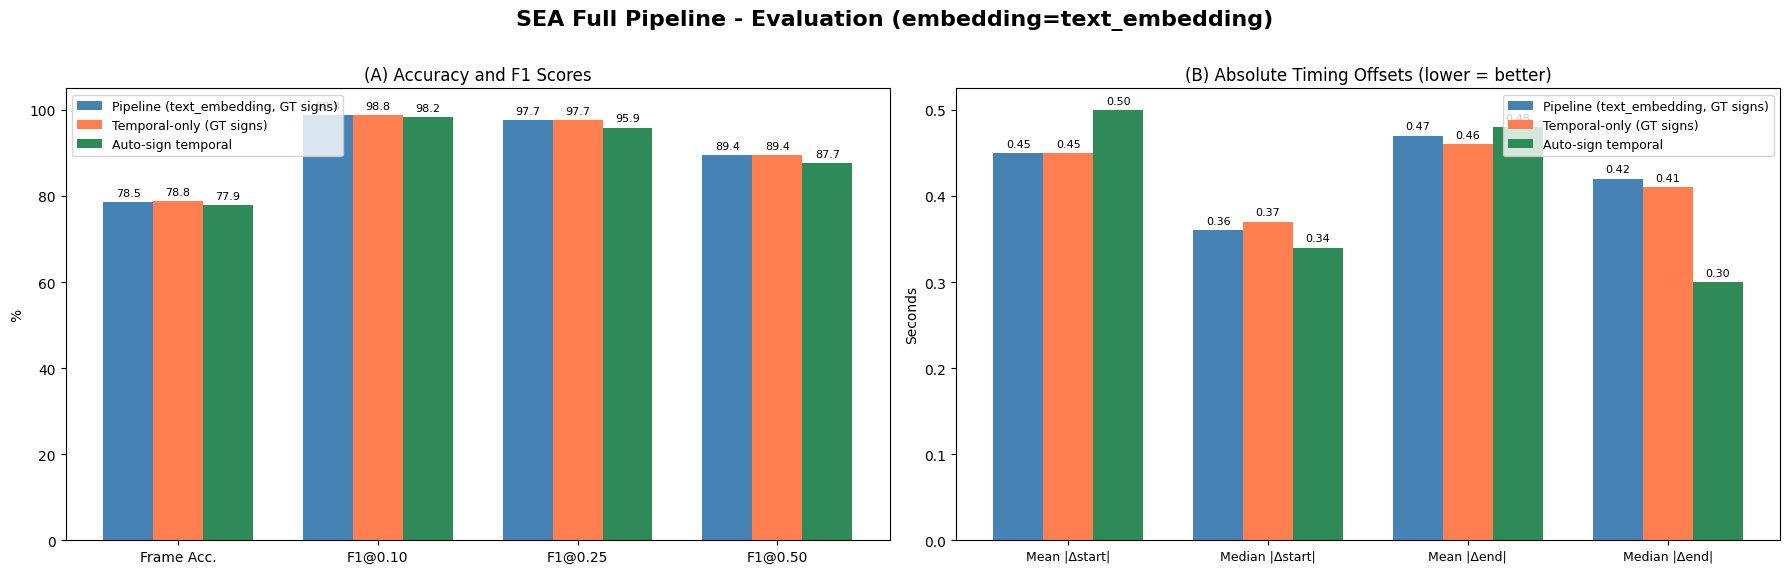

Saved to: C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\assets\evaluation_metrics.png


In [15]:
# -- Evaluation metrics visualisation ------------------------------------------
import re
import numpy as np
import matplotlib.pyplot as plt


def parse_eval_metrics(eval_text):
    metrics = {}
    if not isinstance(eval_text, str):
        return metrics

    patterns = {
        "Frame Acc.": r"Frame-level accuracy:\s*([0-9]+\.?[0-9]*)",
        "F1@0.10": r"F1@0\.10:\s*([0-9]+\.?[0-9]*)",
        "F1@0.25": r"F1@0\.25:\s*([0-9]+\.?[0-9]*)",
        "F1@0.50": r"F1@0\.50:\s*([0-9]+\.?[0-9]*)",
        "start_abs": r"Mean/median start offset \(abs\):\s*([0-9]+\.?[0-9]*)/([0-9]+\.?[0-9]*)",
        "end_abs": r"Mean/median end offset \(abs\):\s*([0-9]+\.?[0-9]*)/([0-9]+\.?[0-9]*)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, eval_text)
        if not m:
            continue
        if key == "start_abs":
            metrics["Mean |Δstart|"] = float(m.group(1))
            metrics["Median |Δstart|"] = float(m.group(2))
        elif key == "end_abs":
            metrics["Mean |Δend|"] = float(m.group(1))
            metrics["Median |Δend|"] = float(m.group(2))
        else:
            metrics[key] = float(m.group(1))

    return metrics


# Use the same three runs as the printed comparison table
m_pipeline = parse_eval_metrics(eval_main)
m_temporal_same_signs = parse_eval_metrics(eval_baseline)
m_auto_temporal = parse_eval_metrics(eval_auto)

if m_pipeline and m_temporal_same_signs and m_auto_temporal:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f"SEA Full Pipeline - Evaluation (embedding={EMBEDDING_MODE})", fontsize=16, fontweight="bold")

    sign_source = "GT signs" if USING_GT_SIGNS else "Auto signs"
    series_labels = [
        f"Pipeline ({EMBEDDING_MODE}, {sign_source})",
        f"Temporal-only ({sign_source})",
        "Auto-sign temporal",
    ]
    series_metrics = [m_pipeline, m_temporal_same_signs, m_auto_temporal]
    series_colors = ["steelblue", "coral", "seagreen"]

    # Panel A: Accuracy and F1
    ax = axes[0]
    labels = ["Frame Acc.", "F1@0.10", "F1@0.25", "F1@0.50"]
    vals = [[m.get(k, 0.0) for k in labels] for m in series_metrics]

    x = np.arange(len(labels))
    w = 0.25
    for i, (label, color, v) in enumerate(zip(series_labels, series_colors, vals)):
        offset = (i - 1) * w
        bars = ax.bar(x + offset, v, w, label=label, color=color)
        for b, val in zip(bars, v):
            ax.text(b.get_x() + b.get_width() / 2, val + 1, f"{val:.1f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("%")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.set_title("(A) Accuracy and F1 Scores")

    # Panel B: Absolute timing offsets
    ax = axes[1]
    labels_b = ["Mean |Δstart|", "Median |Δstart|", "Mean |Δend|", "Median |Δend|"]
    vals_b = [[m.get(k, 0.0) for k in labels_b] for m in series_metrics]

    x = np.arange(len(labels_b))
    for i, (label, color, v) in enumerate(zip(series_labels, series_colors, vals_b)):
        offset = (i - 1) * w
        bars = ax.bar(x + offset, v, w, label=label, color=color)
        for b, val in zip(bars, v):
            if val > 0:
                ax.text(b.get_x() + b.get_width() / 2, val + 0.005, f"{val:.2f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels_b, fontsize=9)
    ax.set_ylabel("Seconds")
    ax.legend(fontsize=9)
    ax.set_title("(B) Absolute Timing Offsets (lower = better)")

    if EVAL_SELF_REFERENCE:
        fig.text(
            0.5,
            0.01,
            "Warning: GT source is not independent from input. Treat metrics as sanity-check only.",
            ha="center",
            color="darkred",
            fontsize=10,
        )

    plt.tight_layout(rect=(0, 0.03, 1, 0.97))
    fig.savefig(ASSETS_DIR / "evaluation_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to: {ASSETS_DIR / 'evaluation_metrics.png'}")
else:
    print("Could not parse evaluation metrics for visualisation.")
    print(f"Parsed keys (pipeline): {sorted(m_pipeline.keys())}")
    print(f"Parsed keys (temporal same signs): {sorted(m_temporal_same_signs.keys())}")
    print(f"Parsed keys (auto temporal): {sorted(m_auto_temporal.keys())}")

---
## Section 8 — Timeline Visualisation

Four-track chart showing a 60-second window (33–93 s):

1. **Auto SIGN** (steel blue) — auto-segmented sign boundaries from Stage 1 (~2,803 segments)
2. **Human Gloss Labeling** (coral) — human-annotated signs, 852 segments (ground truth)
3. **Original CC (input)** (tomato) — CC tier subtitle timestamps as extracted from the EAF (speech-timed; the intro music cue `[เสียงดนตรี]` was at 0–32 s and is off-screen here)
4. **DP-Aligned Output** (sea green) — Stage 3 output; timestamps shifted to align with sign boundaries

C:\Users\USER\AppData\Local\Temp\ipykernel_24032\254118306.py:36: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.savefig(ASSETS_DIR / "alignment_visualization.png", dpi=150, bbox_inches="tight")
C:\Users\USER\AppData\Local\Temp\ipykernel_24032\254118306.py:36: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.savefig(ASSETS_DIR / "alignment_visualization.png", dpi=150, bbox_inches="tight")
C:\Users\USER\AppData\Local\Temp\ipykernel_24032\254118306.py:36: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.savefig(ASSETS_DIR / "alignment_visualization.png", dpi=150, bbox_inches="tight")
C:\Users\USER\AppData\Local\Temp\ipykernel_24032\254118306.py:36: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.savefig(ASSETS_DIR / "alignment_visualization.png", dpi=150, bbox_inches="tight")
C:\Users\USER\AppData\Local\Temp\

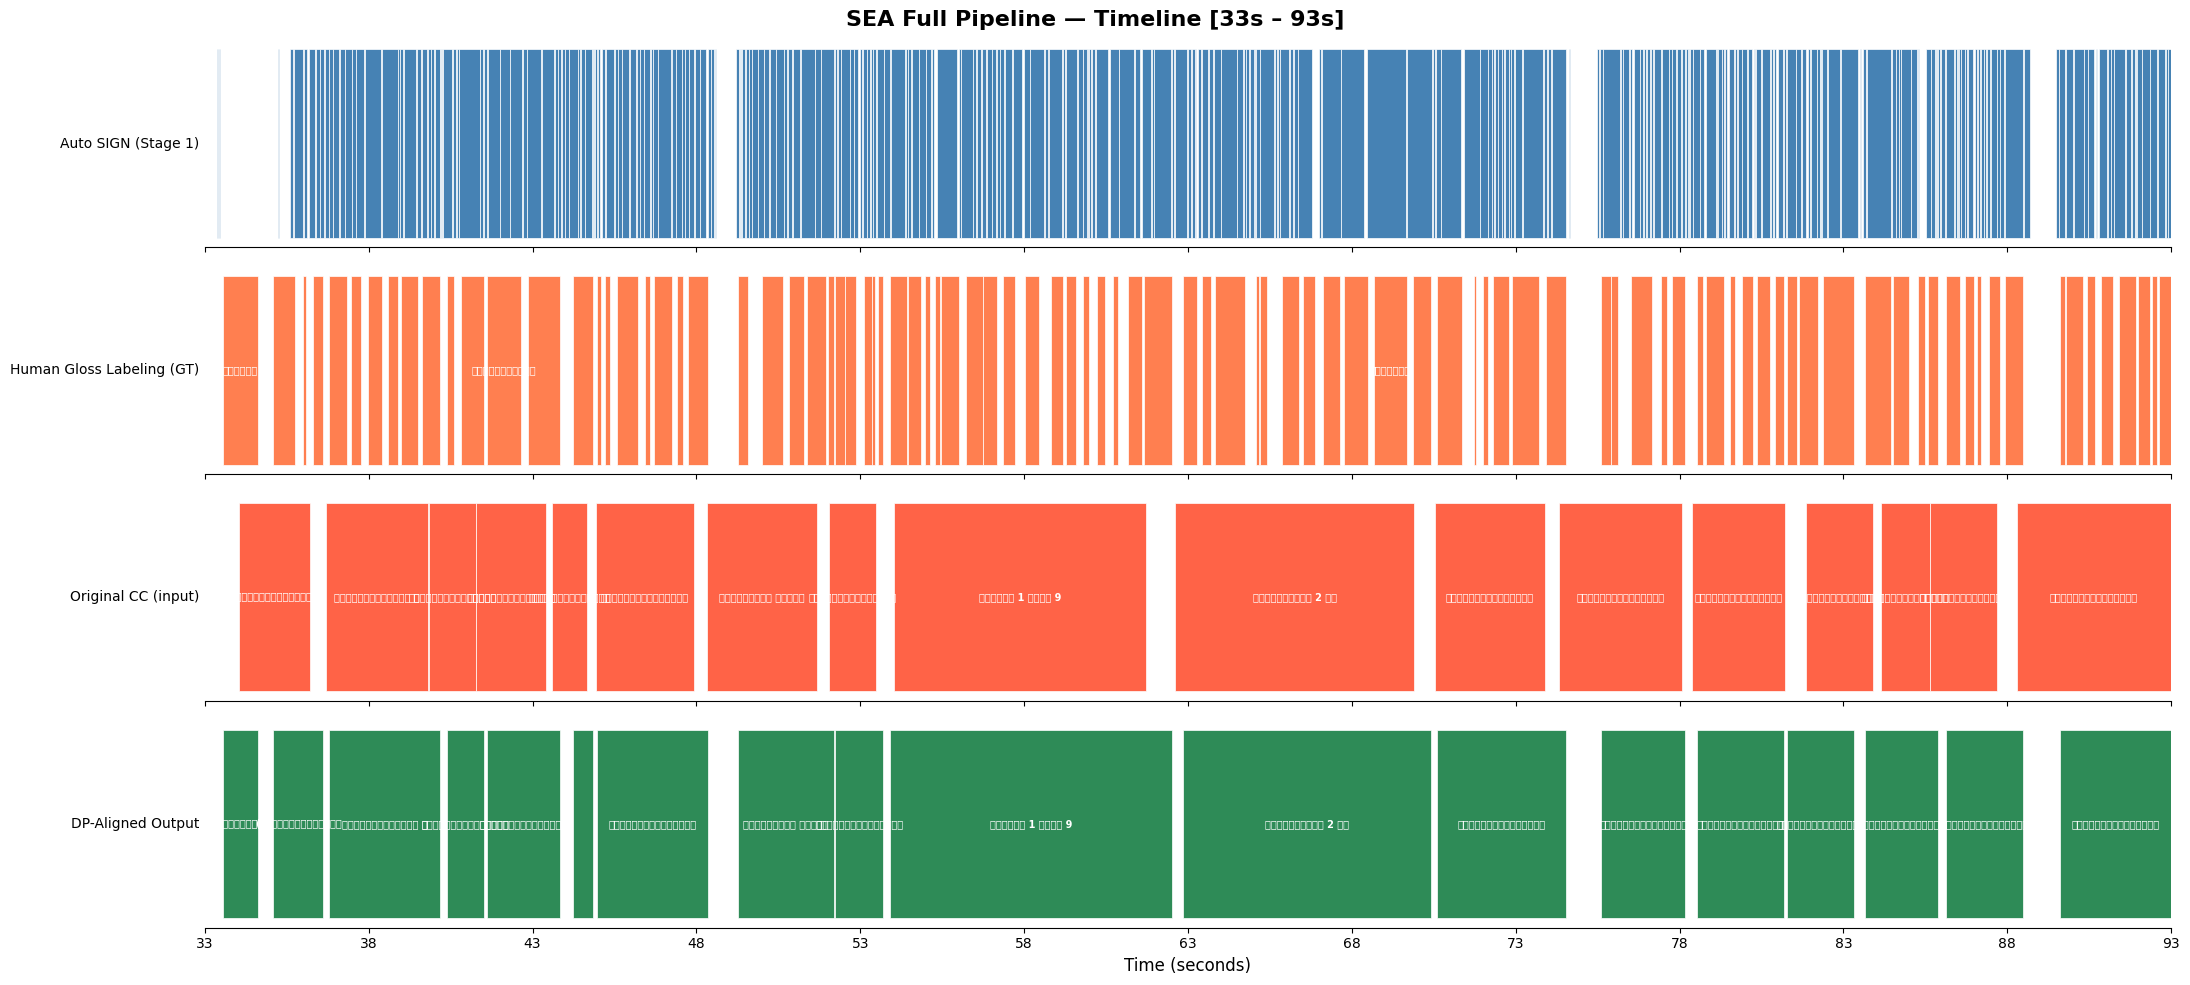

Saved to: C:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\assets\alignment_visualization.png


In [16]:
T_START, T_END = 33.0, 93.0

fig, axes = plt.subplots(4, 1, figsize=(22, 10), sharex=True)
fig.suptitle(f"SEA Full Pipeline \u2014 Timeline [{T_START:.0f}s \u2013 {T_END:.0f}s]",
             fontsize=16, fontweight="bold")

tracks = [
    ("Auto SIGN (Stage 1)",       auto_signs,        "steelblue"),
    ("Human Gloss Labeling (GT)", gt_sign_segments,  "coral"),
    ("Original CC (input)",       cues_original,     "tomato"),
    ("DP-Aligned Output",         cues,              "seagreen"),
]

for ax, (label, segments, color) in zip(axes, tracks):
    for seg in segments:
        s, e = seg["start"], seg["end"]
        if e < T_START or s > T_END:
            continue
        s = max(s, T_START)
        e = min(e, T_END)
        ax.barh(0, e - s, left=s, height=0.6, color=color, edgecolor="white", linewidth=0.5)
        if "text" in seg and seg["text"] and (e - s) > 1.0:
            ax.text((s + e) / 2, 0, seg["text"][:15], ha="center", va="center",
                    fontsize=7, color="white", fontweight="bold", clip_on=True)
    ax.set_ylabel(label, fontsize=10, rotation=0, ha="right", va="center")
    ax.set_yticks([])
    ax.set_xlim(T_START, T_END)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

axes[-1].set_xlabel("Time (seconds)", fontsize=12)
axes[-1].set_xticks(np.arange(T_START, T_END + 1, 5))

plt.tight_layout()
fig.savefig(ASSETS_DIR / "alignment_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {ASSETS_DIR / 'alignment_visualization.png'}")

---
## Section 9 — Summary and Next Steps

### What we accomplished

| Stage | Input | Output | Tool | GPU? |
|-------|-------|--------|------|------|
| **0 — Pose** | `04.mp4` | `04.pose` | `videos_to_poses` (MediaPipe) | Yes |
| **1 — Segment** | `04.pose` | `04.eaf` (SIGN tier) | `pose_to_segments` | No |
| **2 — Embed** | cues + signs | similarity matrix | SentenceTransformer / SignCLIP | Yes |
| **3 — Align** | `.eaf` + `.vtt` + sim | aligned `.vtt` + `_updated.eaf` | `dp_align_subtitles_to_signs()` | No |

### Embedding modes summary

| Mode | Works out of the box? | Needs sign text? | Expected improvement |
|------|-----------------------|-------------------|---------------------|
| `none` | Yes | No | Baseline |
| `text_embedding` | Yes | Yes (uses GT signs) | Moderate |
| `sign_clip_embedding` | No (external setup) | No (uses pose features) | **+6% F1@0.50** |

### Paper benchmark (Table 5 — arXiv:2512.08094)

The paper reports results on BOBSL (British Sign Language) using an **independent human-annotated GT**. Our demo uses a Thai SL video with a reference alignment as GT — these numbers are **not directly comparable**:

| Dataset | Method | F1@0.50 (paper) |
|---------|--------|-----------------|
| BOBSL | SEA multilingual | 50.68% |
| BOBSL | SEA finetuned BSL | 54.50% |
| How2Sign | SEA finetuned ASL | 39.57% |
| WMT-SLT | SEA finetuned DSGS | 77.69% |
| SwissSLi | SEA multilingual | 85.57% |

Our demo achieves F1@0.50 = 89.41% (GT signs) / 87.65% (auto signs) because the GT here is a reference alignment (not human sign-annotation), making the task easier. To reproduce BOBSL-level results, use an independent human GT with `sign_clip_embedding`.

### Paper hyperparameter defaults (Table 5)

| Dataset | b-thresh | o-thresh | w_dur | w_gap | w_sim | window | max_gap |
|---------|----------|----------|-------|-------|-------|--------|---------|
| BOBSL | 30 | **50** | 1 | 5 | 10 | 50 | 10 s |
| How2Sign | 40 | 50 | 5 | 0.8 | 10 | 50 | 8 s |
| WMT-SLT | 20 | 30 | 0.5 | 5 | 5 | 50 | 6 s |
| SwissSLi | 20 | 30 | 0.5 | 5 | 1 | 50 | 6 s |

This demo uses `SIGN_O=70` (vs BOBSL default of 50) because the Thai SL video produces more noisy short segments at lower thresholds. All DP weights (`w_dur=1, w_gap=5, w_sim=10, window=50, max_gap=10`) match the BOBSL defaults.

### Generated files

```
data/example_alignment/pipeline_output/
├── poses/04.pose                              ← Stage 0
├── subtitles/04.vtt                           ← Input VTT (CC tier, 172 cues)
├── ground_truth/04.vtt                        ← Ground truth (aligned_output.vtt, 172 cues)
├── segmentation/E4s-1_30_70/04.eaf            ← Stage 1 (SIGN tier, 2803 segments)
├── segmentation/E4s-1_30_70/04_updated.eaf    ← Stage 3 (SUBTITLE_SHIFTED + SIGN_MERGED tiers)
└── aligned/04.vtt                             ← Stage 3 (aligned subtitles, 172 cues)
```

### Next steps

1. **Try paper BOBSL thresholds** — set `SIGN_B=30, SIGN_O=50` (from Table 5 of arXiv:2512.08094)
2. **Switch embedding modes** — change `EMBEDDING_MODE` in Section 5 and re-run
3. **Set up SignCLIP** — follow the instructions in Section 5 for best results on non-Thai data
4. **Use on your own videos** — provide `.mp4` + `.vtt` and run the same pipeline
5. **Batch processing** — use `SEA/align.py --mode=inference` for multiple videos
6. **Hyperparameter tuning** — use `--mode=training` with random search (~10,000 iterations)